<a href="https://colab.research.google.com/github/nora-tiger/python-basic/blob/master/Data_Visualization_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1) Loading the Taxis Dataset
import seaborn as sns
# Load the 'taxis' dataset
df=sns.load_dataset("taxis")
print(df)
print(df.head())











                  pickup             dropoff  passengers  distance  fare  \
0    2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0   
1    2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0   
2    2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5   
3    2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0   
4    2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0   
...                  ...                 ...         ...       ...   ...   
6428 2019-03-31 09:51:53 2019-03-31 09:55:27           1      0.75   4.5   
6429 2019-03-31 17:38:00 2019-03-31 18:34:23           1     18.74  58.0   
6430 2019-03-23 22:55:18 2019-03-23 23:14:25           1      4.14  16.0   
6431 2019-03-04 10:09:25 2019-03-04 10:14:29           1      1.12   6.0   
6432 2019-03-13 19:31:22 2019-03-13 19:48:02           1      3.85  15.0   

       tip  tolls  total   color      payment            pickup_zone  \
0     2.15    0

In [ ]:
#Check for missing values in the dataset and identify columns with missing data.
print(df.isnull().sum())
# Impute missing values using appropriate strategies based on the column type (e.g.,
# using mean, median, or mode for numerical columns, and mode for categorical
# columns).
# For columns that are critical and cannot be reasonably imputed, remove rows with
# missing values to maintain data integrity
df['payment']=df['payment'].fillna(df['payment'].mode()[0])
df['pickup_zone']=df['pickup_zone'].fillna(df['pickup_zone'].mode()[0])
df['dropoff_zone']=df['dropoff_zone'].fillna(df['dropoff_zone'].mode()[0])
df['pickup_borough']=df['pickup_borough'].fillna(df['pickup_borough'].mode()[0])
df['dropoff_borough']=df['dropoff_borough'].fillna(df['dropoff_borough'].mode()[0])
print(df.isnull().sum())


pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


<Axes: title={'center': 'Fare Over Time'}, xlabel='pickup'>

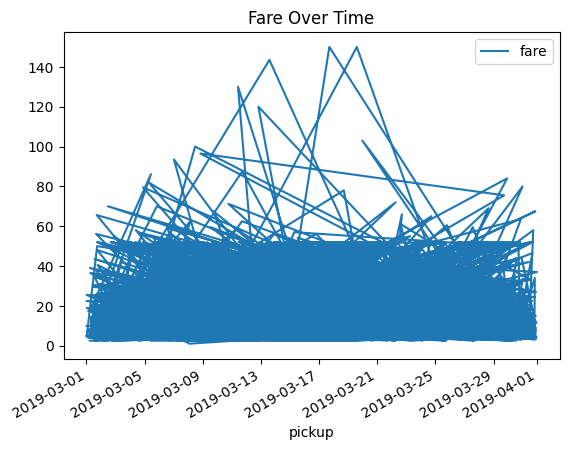

In [ ]:
# 3) Visualizations using Matplotlib/Pandas Plot:
# ★ Line Chart
# Plot a line chart to visualize the fare over time, using the pickup timestamp as the
# x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime
# format before plotting.
import matplotlib.pyplot as plt
import pandas as pd
df['pickup']=pd.to_datetime(df['pickup'])
df.plot(x='pickup',y='fare',kind='line',title='Fare Over Time')

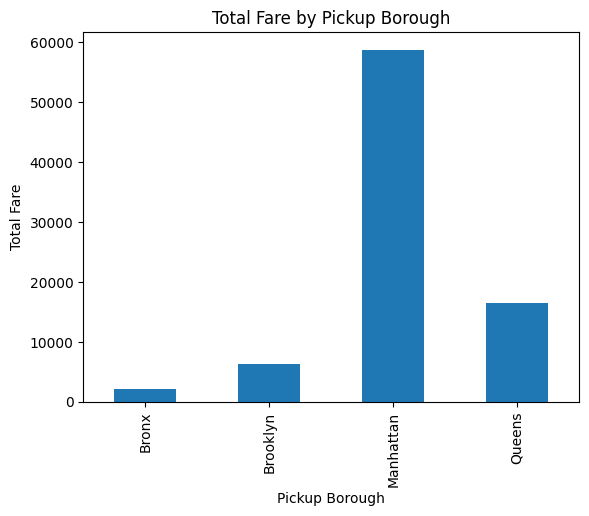

In [ ]:
#  Bar Chart
# Create a bar chart to show the total fare for each pickup_borough. Group the data
# by pickup_borough and sum the fare for each group.

df.groupby('pickup_borough')['fare'].sum().plot(kind='bar')
plt.title('Total Fare by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.show()

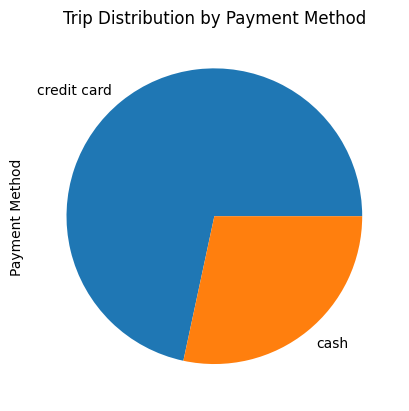

In [ ]:
# Pie Chart
# Plot a pie chart showing the distribution of trips based on the payment method (credit
# card, cash, etc.). Each slice should represent the count of trips for a specific payment
# method.
df['payment'].value_counts().plot(kind='pie')
plt.title('Trip Distribution by Payment Method')
plt.ylabel('Payment Method')
plt.show()

Text(0, 0.5, 'Frequency')

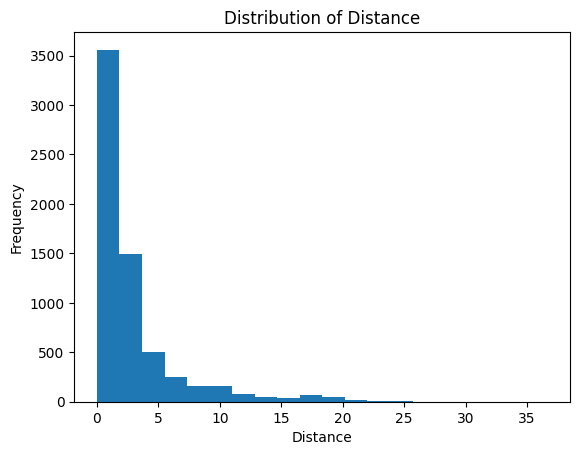

In [ ]:
# Histogram
# Create a histogram to visualize the distribution of distance. Customize the number of
# bins for better granularity and ensure the plot is easy to interpret.
df['distance'].min()
df['distance'].max()
plt.hist(df['distance'],bins=20)
plt.title('Distribution of Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')

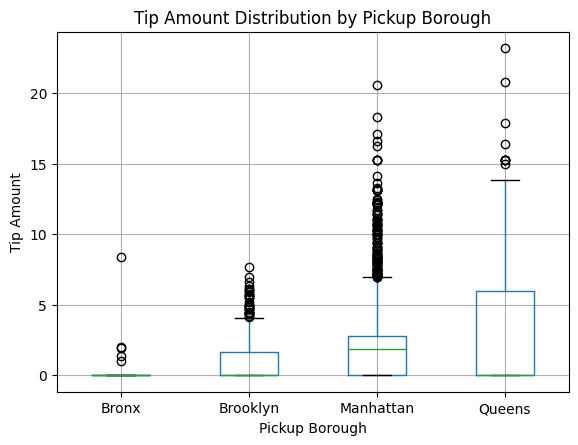

In [ ]:
# Box Plot
# Plot a box plot to visualize the distribution of tip amounts for each pickup_borough.
# Use pickup_borough as the categorical axis and tip as the numeric axis.
df.boxplot(column='tip', by='pickup_borough')
plt.suptitle('')
plt.title('Tip Amount Distribution by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.show()

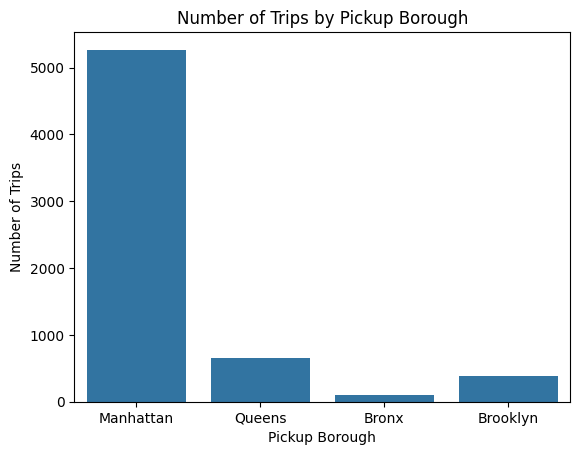

In [ ]:
# Visualizations using Seaborn:
# ★ Count Plot
# Create a count plot to visualize the number of trips in each pickup_borough. The
# x-axis should represent the boroughs, and the y-axis should show the count of trips.
import seaborn as sns
sns.countplot(x='pickup_borough', data=df)
plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.show()

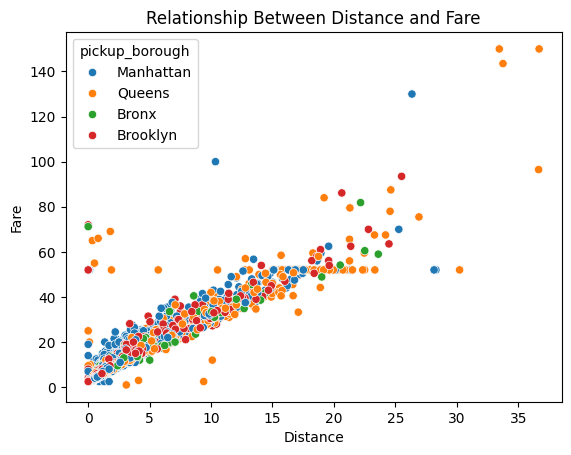

In [ ]:
# Scatter Plot
# Plot a scatter plot to show the relationship between distance and fare. Use
# distance on the x-axis and fare on the y-axis to visualize any correlation. Color the
# points based on the pickup_borough to differentiate the trips by their respective
# boroughs.
sns.scatterplot(
    x='distance',
    y='fare',
    hue='pickup_borough',
    data=df
    )
plt.title('Relationship Between Distance and Fare')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.show()

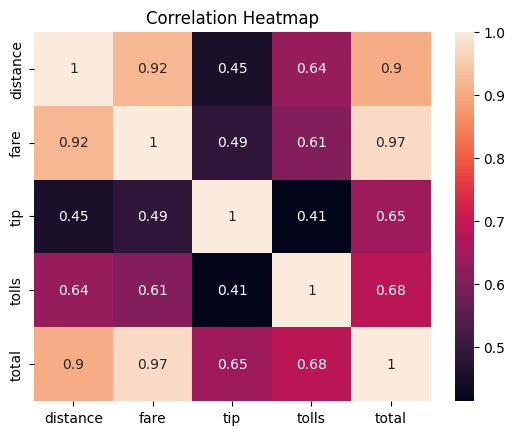

In [ ]:
# Heatmap
# Plot a heatmap to visualize the correlation between numerical variables such as
# distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the
# relationships.
correlation = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()
sns.heatmap(correlation, annot=True)
plt.title('Correlation Heatmap')
plt.show()

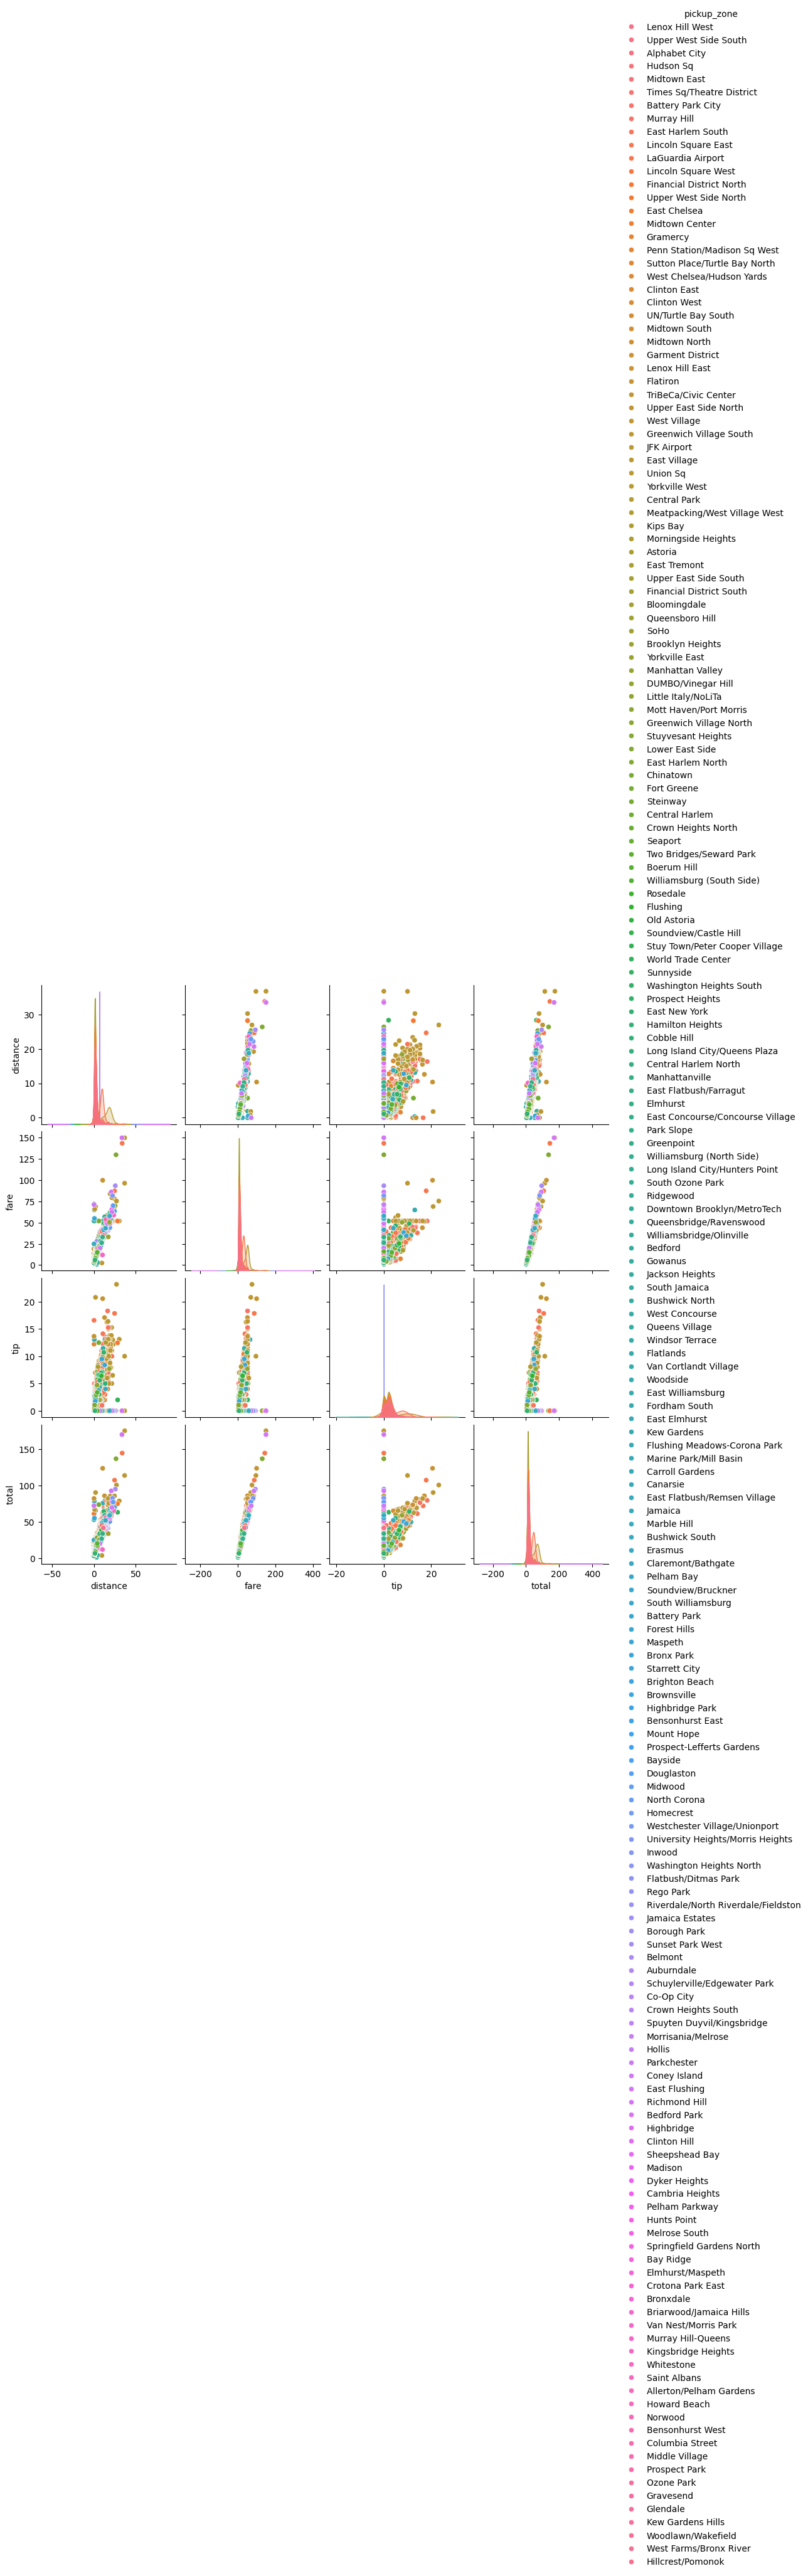

In [ ]:
# Pair Plot
# Create a pair plot to visualize the pairwise relationships between distance, fare, tip,
# and total. Color the data points according to the pickup_zone method to compare
# how different zones affect these variables.
sns.pairplot(
    df[['distance', 'fare', 'tip', 'total', 'pickup_zone']],
    hue='pickup_zone'
)
plt.show()

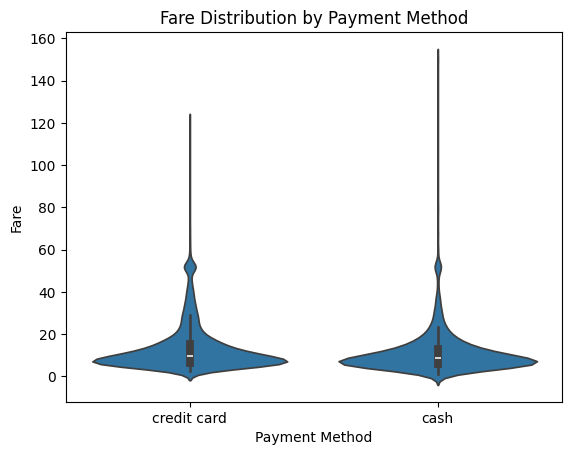

In [ ]:
# Violin Plot
# Plot a violin plot to show the distribution of fare for each payment method. Use the
# payment method as the categorical axis and fare as the numeric axis to visualize its
# distribution.
sns.violinplot(x='payment', y='fare', data=df)
plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.show()